In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path.cwd()
print(DATA_DIR)

# cwd = current working directory. 
# path.cwd() returns a Path object representing the current working directory.
# DATA_DIR is a variable that stores the current working directory as a Path object.

# Path.cwd() is a method from the pathlib module that is more portable and flexible
# If I share this code they can run it on their machine without changing the path.
# Path.cwd() automatically finds their current folder


/Users/dinareitan/Coding/BBS


# Info and pre-exhibit check of datasets

In [57]:
# ============================================================
# Info and pre-exhibit check of datasets
# Run this once at the top of the notebook, before Exhibit 1
# ============================================================

sources = pd.read_csv(DATA_DIR / "sources.csv")
dictionary = pd.read_csv(DATA_DIR / "data_dictionary.csv")
# load these two reference files once — they describe every other file in the project

def check_file(df, filename, source_keyword):
    # df: the dataframe to check (e.g. slp)
    # filename: the exact name used in data_dictionary.csv's "file" column
    # source_keyword: text to search for in sources.csv's "dataset" column

    print(f"\n########## {filename} ##########")

    print("--- Source ---")
    matched_source = sources[sources["dataset"].str.contains(source_keyword, case=False)]
    if len(matched_source) > 0:
        print(matched_source)
    else:
        print("(no direct entry in sources.csv — likely derived from another source)")
    # .str.contains() searches text within a column, not an exact match —
    # needed because sources.csv's dataset names don't exactly match the CSV filenames
    # the if/else avoids printing an empty, confusing table when there's no match

    print("\n--- Field definitions ---")
    print(dictionary[dictionary["file"] == filename])
    # exact match on filename, since data_dictionary.csv uses precise file names

    print("\n--- Shape and column types ---")
    print(df.shape)          # (rows, columns) — should be 35,136 rows for the quarter-hour files
    print(df.dtypes)         # data type of each column — catches "still a string" mistakes early

    print("\n--- Missing values ---")
    print(df.isna().sum())   # count of missing cells per column — should all read 0

    print("\n--- Preview ---")
    print(df.head())


# --- Load every dataset once, and check each one ---

slp = pd.read_csv(DATA_DIR / "slp_profiles.csv")
check_file(slp, "slp_profiles.csv", "Berlin SLP")

futures = pd.read_csv(DATA_DIR / "futures_prices.csv")
check_file(futures, "futures_prices.csv", "futures")

shape = pd.read_csv(DATA_DIR / "shape_factors.csv")
check_file(shape, "shape_factors.csv", "shape")

day_ahead = pd.read_csv(DATA_DIR / "day_ahead_prices.csv")
check_file(day_ahead, "day_ahead_prices.csv", "Day-Ahead")

imbalance = pd.read_csv(DATA_DIR / "imbalance_prices.csv")
check_file(imbalance, "imbalance_prices.csv", "reBAP")

actual_load = pd.read_csv(DATA_DIR / "actual_portfolio_load.csv")
check_file(actual_load, "actual_portfolio_load.csv", "actual portfolio")
# not needed until later (Stage 5, imbalance settlement) — loaded here so you
# already know its structure before you get there


########## slp_profiles.csv ##########
--- Source ---
         dataset              publisher    status  \
0  Berlin SLP HB  Stromnetz Berlin GmbH  observed   
1  Berlin SLP GB  Stromnetz Berlin GmbH  observed   
2  Berlin SLP LB  Stromnetz Berlin GmbH  observed   

                                                 url  
0  https://www.stromnetz.berlin/files/globalasset...  
1  https://www.stromnetz.berlin/files/globalasset...  
2  https://www.stromnetz.berlin/files/globalasset...  

--- Field definitions ---
               file             column  \
0  slp_profiles.csv      timestamp_utc   
1  slp_profiles.csv    timestamp_local   
2  slp_profiles.csv  hb_normalized_kwh   
3  slp_profiles.csv  gb_normalized_kwh   
4  slp_profiles.csv  lb_normalized_kwh   

                                         description            data_status  
0       Quarter-hour start in UTC; primary join key.  observed/preprocessed  
1  Quarter-hour start in Europe/Berlin with UTC o...  observed/preprocessed 

# Exhibit 1

In [ ]:
# Load and change timestamps

slp = pd.read_csv(DATA_DIR / "slp_profiles.csv")

# change the timestamp column from string to datetime object
slp["timestamp_utc"] = pd.to_datetime(slp["timestamp_utc"], utc=True)
# resolve to UTC first (avoids ambiguity from the +01:00/+02:00 DST switch), 
# then relabel as Berlin time
slp["timestamp_local"] = pd.to_datetime(slp["timestamp_local"], utc=True).dt.tz_convert("Europe/Berlin")

slp.head()

,timestamp_utc,timestamp_local,hb_normalized_kwh,gb_normalized_kwh,lb_normalized_kwh
0,2023-12-31 23:00:00+00:00,2024-01-01 00:00:00+01:00,27.110,15.705,17.028
1,2023-12-31 23:15:00+00:00,2024-01-01 00:15:00+01:00,25.127,15.158,16.454
2,2023-12-31 23:30:00+00:00,2024-01-01 00:30:00+01:00,23.237,14.636,16.030
3,2023-12-31 23:45:00+00:00,2024-01-01 00:45:00+01:00,21.409,14.164,15.706
4,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+01:00,19.643,13.741,15.482


In [13]:
# Scale each profile to its customer group

# dictionary on dictionary of 
# customer groups, number of customers and annual consumption
customers = {
    'hb' : {'n': 10_000, 'e': 3.5},         # household, 10k customers, 3.5 MWh/day
    'gb' : {'n': 200, 'e': 30.0},           # commercial, 200 customers, 30 MWh/day
    'lb' : {'n': 20, 'e': 100.0}            # agriculture, 20 customers, 100 MWh/day
}

for p, c in customers.items():
    # total energy for this profile
    E_p = c['n'] * c['e']
    # SLP annual sum for this profile                  
    S_p = slp[f'{p}_normalized_kwh'].sum()
    # multiplier to scale SLP to match expected energy  
    scale = E_p / S_p      
    # apply the scaling factor to the normalized kWh profile to get MWh                 
    slp[f'{p}_load_mwh'] = slp[f'{p}_normalized_kwh'] * scale
    # print the results for the profiles
    print(f"{p}: E_p={E_p} MWh, S_p={S_p:.1f} kWh, scale={scale:.3f}, "
          f"reconciled sum={slp[f'{p}_load_mwh'].sum():.1f} MWh")

# Load = how much electricity is being consumed at a given time, in MWh
# similar to demand/consumption
# total_load_mwh = how much electricity (in MWh) the entire customer portfolio 
# consumes in each 15 minutes

hb: E_p=35000.0 MWh, S_p=1000000.0 kWh, scale=0.035, reconciled sum=35000.0 MWh
gb: E_p=6000.0 MWh, S_p=1000000.0 kWh, scale=0.006, reconciled sum=6000.0 MWh
lb: E_p=2000.0 MWh, S_p=1000000.0 kWh, scale=0.002, reconciled sum=2000.0 MWh


In [14]:
# Total portfolio and reconciliation check

slp["total_load_mwh"] = slp["hb_load_mwh"] + slp["gb_load_mwh"] + slp["lb_load_mwh"]
# add a new column to the dataframe that is the sum of the three group columns

total = slp["total_load_mwh"].sum()
# add up the rows in the total column to get the total portfolio energy

expected = 10_000 * 3.5 + 200 * 30.0 + 20 * 100.0
# the known target from the customer table (35,000 + 6,000 + 2,000)

print("Total portfolio energy:", total, "MWh")
print("Expected:", expected, "MWh")

Total portfolio energy: 43000.0 MWh
Expected: 43000.0 MWh


In [ ]:
# Annual energy and % share by customer group

for p in customers:
    # Sum the load for each customer group
    group_total = slp[f"{p}_load_mwh"].sum()
    print(f"{p.upper()}: {group_total:,.0f} MWh ({group_total/total*100:.1f}%)")

HB: 35,000 MWh (81.4%)
GB: 6,000 MWh (14.0%)
LB: 2,000 MWh (4.7%)


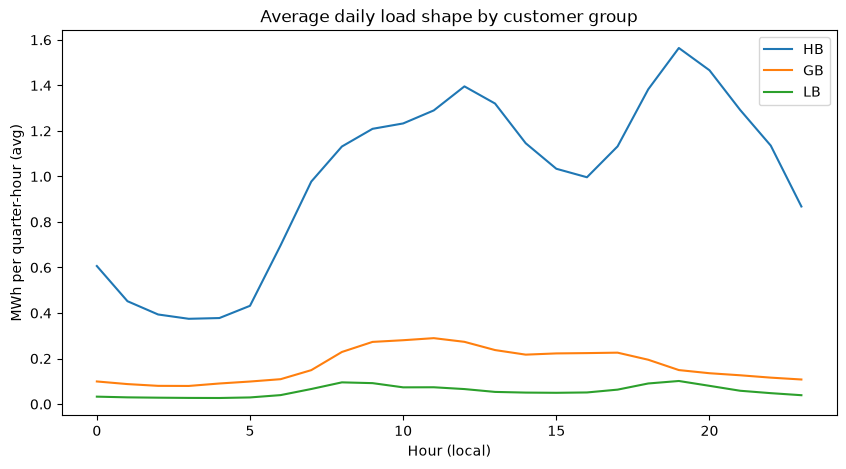

In [16]:
# Average daily shape (pattern) per customer group

# Add a new column to the dataframe that is the hour of the day (0-23)
slp["hour"] = slp["timestamp_local"].dt.hour
# Group by hour and take the mean of the three group columns
# collapses the whole year into one typical 24-hour shape per profile
daily = slp.groupby("hour")[["hb_load_mwh", "gb_load_mwh", "lb_load_mwh"]].mean()

# plot the average daily
daily.plot(figsize=(10, 5))
# label the chart so it is readable on its own
plt.title("Average daily load shape by customer group")
plt.xlabel("Hour (local)")
plt.ylabel("MWh per quarter-hour (avg)")
# name each line in the legend
plt.legend(["HB", "GB", "LB"])
plt.show()

               HB        GB        LB
Weekday  0.977308  0.187333  0.057128
Weekend  1.043544  0.129027  0.056402


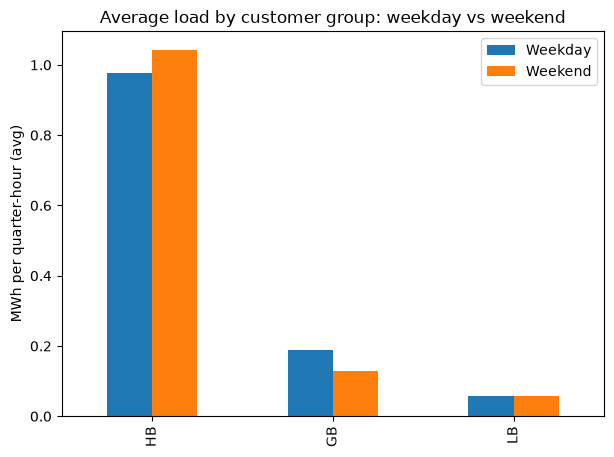

In [19]:
# Weekday vs weekend comparison

# creates a new column that is True if the day is Saturday or Sunday, False otherwise
slp["is_weekend"] = slp["timestamp_local"].dt.weekday >= 5

# group by the new column and take the mean of the three group columns
wk = slp.groupby("is_weekend")[["hb_load_mwh", "gb_load_mwh", "lb_load_mwh"]].mean()
# renameing the index and columns to be more readable
wk.index = ["Weekday", "Weekend"]
wk.columns = ["HB", "GB", "LB"]   
# show the table: 2 rows (weekday, weekend) and 3 columns (customer groups)
print(wk)

wk.T.plot(kind="bar", figsize=(7, 5))
# using .T to transpose the dataframe so that the customer groups are on the x-axis
plt.title("Average load by customer group: weekday vs weekend")
plt.ylabel("MWh per quarter-hour (avg)")
plt.show()

# Using the _local column because _utc could misclassify a day near midnight
# .dt.weekday returns 0-6 for Mon-Sun, so >=5 is Sat/Sun
# >= 5 compares "is this row's weekday number 5 or higher?"

**Exhibit 1 — Customer Portfolio**

*How the standard load profiles were scaled*

Each SLP column (`hb_normalized_kwh`, `gb_normalized_kwh`, `lb_normalized_kwh`) is a normalized shape, not a real quantity — every profile sums to exactly 1,000,000 kWh annually regardless of actual customer count. To convert each shape into real MWh, we first calculated the target annual energy for each customer group directly from the customer table (n × e): HB = 10,000 × 3.5 = 35,000 MWh, GB = 200 × 30.0 = 6,000 MWh, LB = 20 × 100.0 = 2,000 MWh. Dividing each target by the corresponding SLP's own annual sum (1,000,000 kWh in every case) gives a single scale factor per profile: 0.035 for HB, 0.006 for GB, 0.002 for LB. Applying that one multiplier uniformly across all 35,136 quarter-hours preserves the relative shape of each profile exactly, while rescaling its overall size to match the real portfolio.

*Reconciliation*

Summing each scaled profile confirms the scaling was applied correctly: HB reconciles to 35,000.0 MWh, GB to 6,000.0 MWh, and LB to 2,000.0 MWh — each matching its target exactly. Adding the three scaled profiles together gives a total portfolio energy of 43,000.0 MWh, which matches the expected total from the customer table (10,000×3.5 + 200×30 + 20×100 = 43,000 MWh) exactly. This confirms no energy was gained or lost in the scaling process.

*Annual energy and percentage share by customer group*

| Group | Annual energy | Share of portfolio |
|---|---|---|
| HB (household) | 35,000 MWh | 81.4% |
| GB (commercial) | 6,000 MWh | 14.0% |
| LB (agriculture) | 2,000 MWh | 4.7% |

Despite having far fewer customers than HB (10,000 vs. 200 vs. 20), the household segment dominates total energy by a wide margin — its combination of high customer count and moderate per-customer consumption outweighs GB's higher per-customer consumption and LB's very high per-customer consumption, since both groups have far smaller customer counts.

*Average daily shapes*

The three groups show clearly distinct intraday patterns. HB peaks in the morning (~08:00) and again more sharply in the evening (~19:00–20:00), with a trough overnight — consistent with residential activity concentrated around waking, leaving, and returning home. GB shows a flatter, business-hours-shaped bump, rising through the morning and staying elevated across the working day before tapering off in the evening — consistent with commercial operating hours. LB is much smaller in magnitude and peaks around midday and early evening, with less pronounced troughs, consistent with agricultural operations running throughout the day.

*Weekday vs. weekend comparison*

| Group | Weekday | Weekend | Change |
|---|---|---|---|
| HB | 0.977 MWh | 1.044 MWh | +6.8% on weekends |
| GB | 0.187 MWh | 0.129 MWh | −31.1% on weekends |
| LB | 0.057 MWh | 0.056 MWh | ~flat |

HB and GB move in opposite directions: household consumption rises modestly on weekends (people spend more time at home), while commercial consumption drops sharply (many businesses reduce or close operations). LB shows negligible difference, consistent with agricultural operations running on a similar schedule regardless of the day of week.

*How the customer mix incluences the supplier's total load shape*

Because HB accounts for 81.4% of total portfolio energy, the supplier's total load shape is overwhelmingly driven by residential consumption patterns — the double-peaked morning/evening daily shape and the slight weekend increase both carry through to the portfolio as a whole. GB's opposite weekday-favoring pattern is present but too small in absolute terms to reverse this effect; instead, it partially offsets HB's weekend increase, meaning the portfolio's total weekday-vs-weekend difference is smaller than either individual group's swing in isolation. Practically, this means the supplier's overall demand is close to daily/weekly amplitude typical of a residential-driven customer base, and any hedging or forecasting approach should prioritize matching the household demand shape, since it is the dominant driver of total portfolio load.

# Exhibit 2

In [ ]:
# Load and inspect

futures = pd.read_csv(DATA_DIR / "futures_prices.csv")
futures.head()

# The expression DATA_DIR / "futures_prices.csv" uses the / operator to join 
# the path of the current working directory (DATA_DIR) with the filename 
# "futures_prices.csv". This creates a path to the CSV file, which is then
# passed to pd.read_csv() to read the data into a pandas DataFrame called futures

# DATA_DIR / "futures_prices.csv" builds the path /Users/dinareitan/Coding/BBS/futures_prices.csv

,quote_date,delivery_year,load_type,product_type,delivery_period,delivery_start,delivery_end_exclusive,price_eur_mwh,market_activity
0,2023-09-29,2024,BASE,YEAR,CAL,2024-01-01,2025-01-01,77.26,5000
1,2023-09-29,2024,PEAK,YEAR,CAL,2024-01-01,2025-01-01,86.60,1400
2,2023-09-29,2024,BASE,QUARTER,Q1,2024-01-01,2024-04-01,66.42,3000
3,2023-09-29,2024,PEAK,QUARTER,Q1,2024-01-01,2024-04-01,77.70,840
4,2023-09-29,2024,BASE,QUARTER,Q2,2024-04-01,2024-07-01,66.23,2200


In [22]:
# Put delivery periods in a sensible order

period_order = ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 
                'M01', 'M02', 'M03', 'M04', 'M05', 'M06', 
                'M07', 'M08', 'M09', 'M10', 'M11', 'M12']

# the csv does not store periods in a sensible order, 
# so I will use this list to sort them later

In [24]:
# Reshape the data: one row per period, one column per load type

price_by_period = futures.pivot(index="delivery_period", columns="load_type", values="price_eur_mwh")
# pivot: turns the "load_type" values into column headers, 
# with "delivery_period" as the index and "price_eur_mwh" as the values in the table

price_by_period = price_by_period.reindex(period_order)
# reorder the rows of the pivoted table to match the desired period order
# follow calendar order instead of default alphabetical order

activity_by_period = futures.pivot(index="delivery_period", columns="load_type", values="market_activity")
activity_by_period = activity_by_period.reindex(period_order)
# same as for price but for market activity (volume) instead of price

print(price_by_period)
print(activity_by_period)

load_type          BASE    PEAK
delivery_period                
CAL               77.26   86.60
Q1                66.42   77.70
Q2                66.23   64.76
Q3                74.74   69.07
Q4               101.39  134.42
M01               75.32   88.68
M02               60.09   70.59
M03               63.45   72.79
M04               67.11   72.56
M05               60.96   52.40
M06               79.64   80.57
M07               59.45   49.47
M08               84.80   74.16
M09               73.06   76.62
M10               91.85  111.59
M11              106.66  140.84
M12              112.07  159.75
load_type        BASE  PEAK
delivery_period            
CAL              5000  1400
Q1               3000   840
Q2               2200   616
Q3               1600   448
Q4               1400   392
M01               900   252
M02               800   224
M03               650   182
M04                10     3
M05                 8     2
M06                 7     2
M07                 6     2


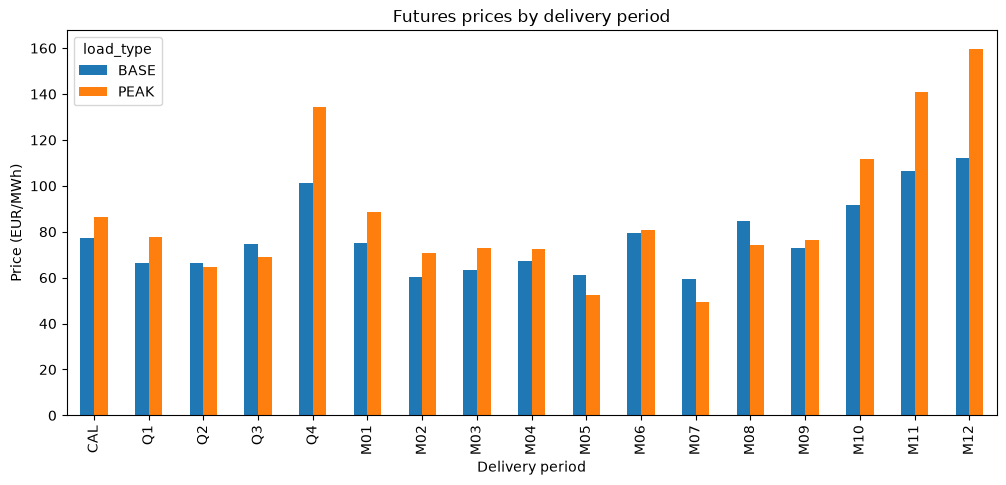

In [25]:
# Plot Base and Peak prices by delivery period

price_by_period.plot(kind='bar', figsize=(12, 5))
# One grouped bar chart: 2 bars (Base, Peak) per delivery period

plt.title("Futures prices by delivery period")
plt.xlabel("Delivery period")
plt.ylabel("Price (EUR/MWh)")
plt.show()

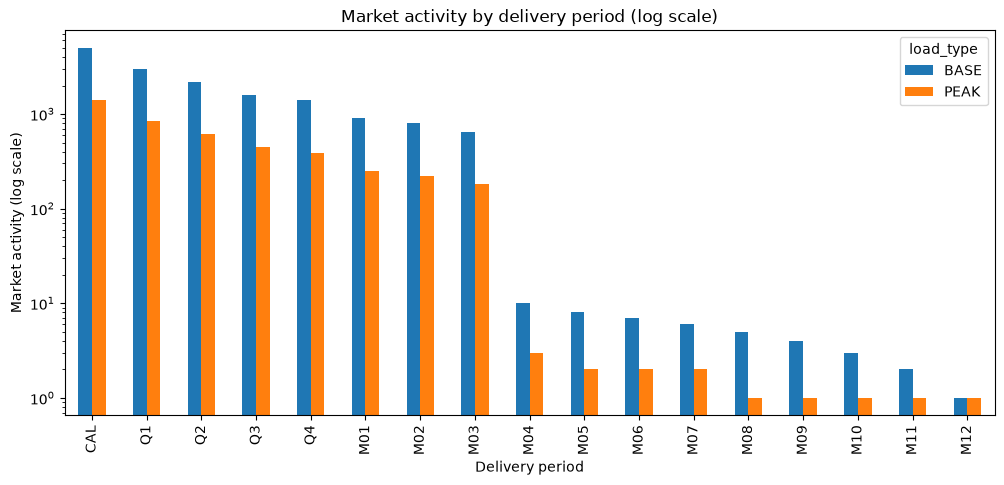

In [26]:
# Plot market_activity by delivery period

activity_by_period.plot(kind='bar', figsize=(12, 5), logy=True)
# logy=True: use a logarithmic y-axis because the market activity values ranges from 1 to 5000
# on a normal scale, the small montly values would be invisible compared to CAL/Q1's larger values

plt.title('Market activity by delivery period (log scale)')
plt.xlabel("Delivery period")
plt.ylabel("Market activity (log scale)")
plt.show()

In [27]:
# Apply a tradability threshold and classify products

THRESHOLD = 100
# chosen by inspecting the log-sclae chart above and seeing that the monthly products are very thinly traded,
# a cliff between CAL/Q1-Q4/M01-M03 and M04-M12 

futures['eligible'] = futures['market_activity'] >= THRESHOLD
# creates a True/False column:
# True if the row's prodict is liquid enough to be considered tradable, 
# False otherwise

usable = sorted(futures.loc[futures['eligible'], 'delivery_period'].unique())
# creates a list of the unique delivery periods that are tradable, sorted alphabetically
illiquid = sorted(futures.loc[~futures['eligible'], 'delivery_period'].unique())
# creates a list of the unique delivery periods that are not tradable, sorted alphabetically
# ~ is the negation operator, so ~futures['eligible'] is True for illiquid products
# meaning that ~ flips True/False, so thiw grabs everything BELOW the threshold

print("Tradable products:", usable)
print("Illiquid products:", illiquid)


Tradable products: ['CAL', 'M01', 'M02', 'M03', 'Q1', 'Q2', 'Q3', 'Q4']
Illiquid products: ['M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']


**Exhibit 2 — Answering the bullet points**

*Market activity criterion*

`market_activity ≥ 100`. Looking at the log-scale chart, CAL (5000), Q1–Q4 (392–3,000), and M01–M03 (650–900) form a clearly distinct, actively-traded cluster, while M04–M12 collapse to single digits (1–10) — a gap of roughly two orders of magnitude separates the two groups, so 100 sits safely in that gap regardless of the exact cutoff chosen within it.

*Usable products*

CAL2024, Q1, Q2, Q3, Q4, M01, M02, M03 (Base and Peak versions of each).

*Illiquid products*

M04 through M12 — nine months' worth of monthly contracts with market_activity in the single digits, unreliable as a basis for real trading decisions.

*Non-overlapping ways of covering 2024 using only usable products*

1. *CAL2024 alone*: one annual Base/Peak pair covering the whole year.
2. *Q1 + Q2 + Q3 + Q4*: four quarterly Base/Peak pairs, together covering all twelve months once each.
3. *M01 + M02 + M03 + Q2 + Q3 + Q4*: the finest combination achievable using only usable products: monthly detail for Jan–Mar (where monthly liquidity survives), quarterly for the rest of the year (where only quarterly liquidity survives).

*Seasonal pattern*

Prices rise sharply toward year-end — Q4 Base (101.39) is well above Q1–Q3 Base (~63–75), and within Q4 the monthly prices climb further (M10 91.85 → M11 106.66 → M12 112.07 Base), consistent with higher winter heating demand pushing prices up. Peak prices follow the same pattern even more sharply (Q4 Peak 134.42; M12 Peak 159.75). In spring and summer — Q2 (Base 66.23 vs. Peak 64.76), Q3 (74.74 vs. 69.07), and months M05, M07, M08 — the Peak price actually falls *below* the Base price, an inversion not seen in any autumn/winter period. This plausibly reflects solar generation depressing daytime (Peak-hour) prices specifically during the sunniest months, an effect winter lacks.

*Conclusion*

*Coarse hedge*: the trading desk could use **CAL2024 Base + CAL2024 Peak** — a single annual pair of positions, using the most liquid product available (market_activity 5,000/1,400), giving the simplest possible hedge with minimal contracts to manage.

*Granular hedge*: the trading desk could use **M01 + M02 + M03 (Base/Peak) followed by Q2 + Q3 + Q4 (Base/Peak)** — six pairs of positions in total. This is the finest hedge achievable while staying entirely within products that pass the liquidity threshold: month-level precision for Jan–Mar, where monthly contracts are still liquid, falling back to quarter-level precision for Apr–Dec, where monthly liquidity has dried up. Both options use only usable (liquid) products and, together, represent the two ends of the coarse-to-granular spectrum the desk can meaningfully choose between.

*Why overlapping annual, quarterly, and monthly full-volume positions would not be an appropriate comparison*

Taking full-size positions in CAL2024, Q1, *and* M01 simultaneously would mean January is covered three times over — once through the annual contract, once through the quarterly contract, and once through the monthly contract — rather than hedged once. The same double- or triple-counting would occur for every month inside Q1. This isn't a more thorough or more conservative hedge; it's simply an internally inconsistent position that inflates total volume and cost without representing any real trading intention. A meaningful comparison between a "coarse" and a "granular" hedge requires each to be built from its own single, internally consistent, non-overlapping partition of the year — using CAL alone *or* the quarters alone *or* the monthly/quarterly mix alone, never several of these layered on top of each other at full size. Only then does the comparison isolate the actual variable of interest (how finely the year is sliced), rather than conflating it with simply holding more volume overall.

# Exhibit 3

In [29]:
# Load and inspect

shape = pd.read_csv(DATA_DIR / "shape_factors.csv")
shape['timestamp_local'] = pd.to_datetime(shape['timestamp_local'], utc=True).dt.tz_convert("Europe/Berlin")
# same UTC-first conversion pattern as in Exhibit 1

shape.head()

,timestamp_utc,timestamp_local,month,hour,weekday,is_peak,historical_shape_factor
0,2023-12-31T23:00:00Z,2024-01-01 00:00:00+01:00,1,0,0,0,0.832554
1,2023-12-31T23:15:00Z,2024-01-01 00:15:00+01:00,1,0,0,0,0.832554
2,2023-12-31T23:30:00Z,2024-01-01 00:30:00+01:00,1,0,0,0,0.832554
3,2023-12-31T23:45:00Z,2024-01-01 00:45:00+01:00,1,0,0,0,0.832554
4,2024-01-01T00:00:00Z,2024-01-01 01:00:00+01:00,1,1,0,0,0.796187


In [ ]:
# Confirm the annual average is close to 1

print("Annual average shape factor:", shape['historical_shape_factor'].mean())
# should print something very close to 1, because the shape factors are normalized to sum to 1 over the year
# taking the mean of the column historical_shape_factor

Annual average shape factor: 1.0000000000876594


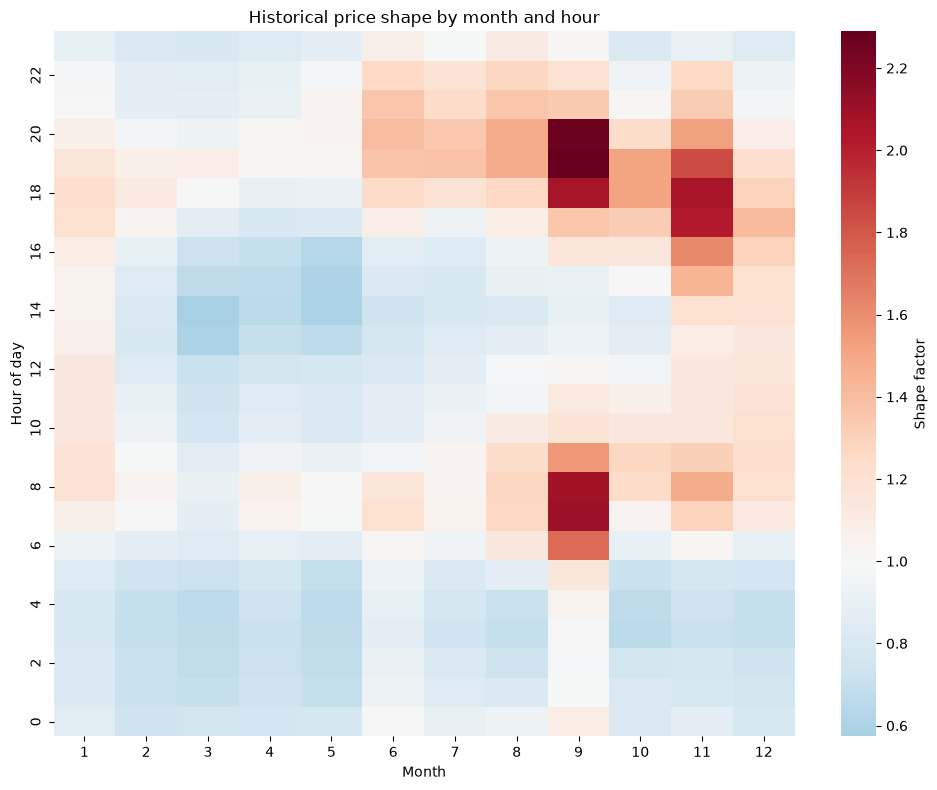

In [42]:
pivot_all = shape.pivot_table(index='hour', columns='month',
                              values='historical_shape_factor', aggfunc='mean')
# each cell = the average shape factor for that hour+month combination

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_all, cmap='RdBu_r', center=1.0, 
            cbar_kws={'label': 'Shape factor'}, yticklabels=2)
# cmap: red = above 1 (expensive hours), blue = below 1 (cheap hours)
#center: makes 1.0 the visual midpoint of the color scale, 
# so that red and blue are balanced around 1.0

plt.title("Historical price shape by month and hour")
plt.xlabel("Month")
plt.ylabel("Hour of day")
plt.gca().invert_yaxis()  # so that hour 0 is at the bottom of the chart
plt.tight_layout()

plt.show() 


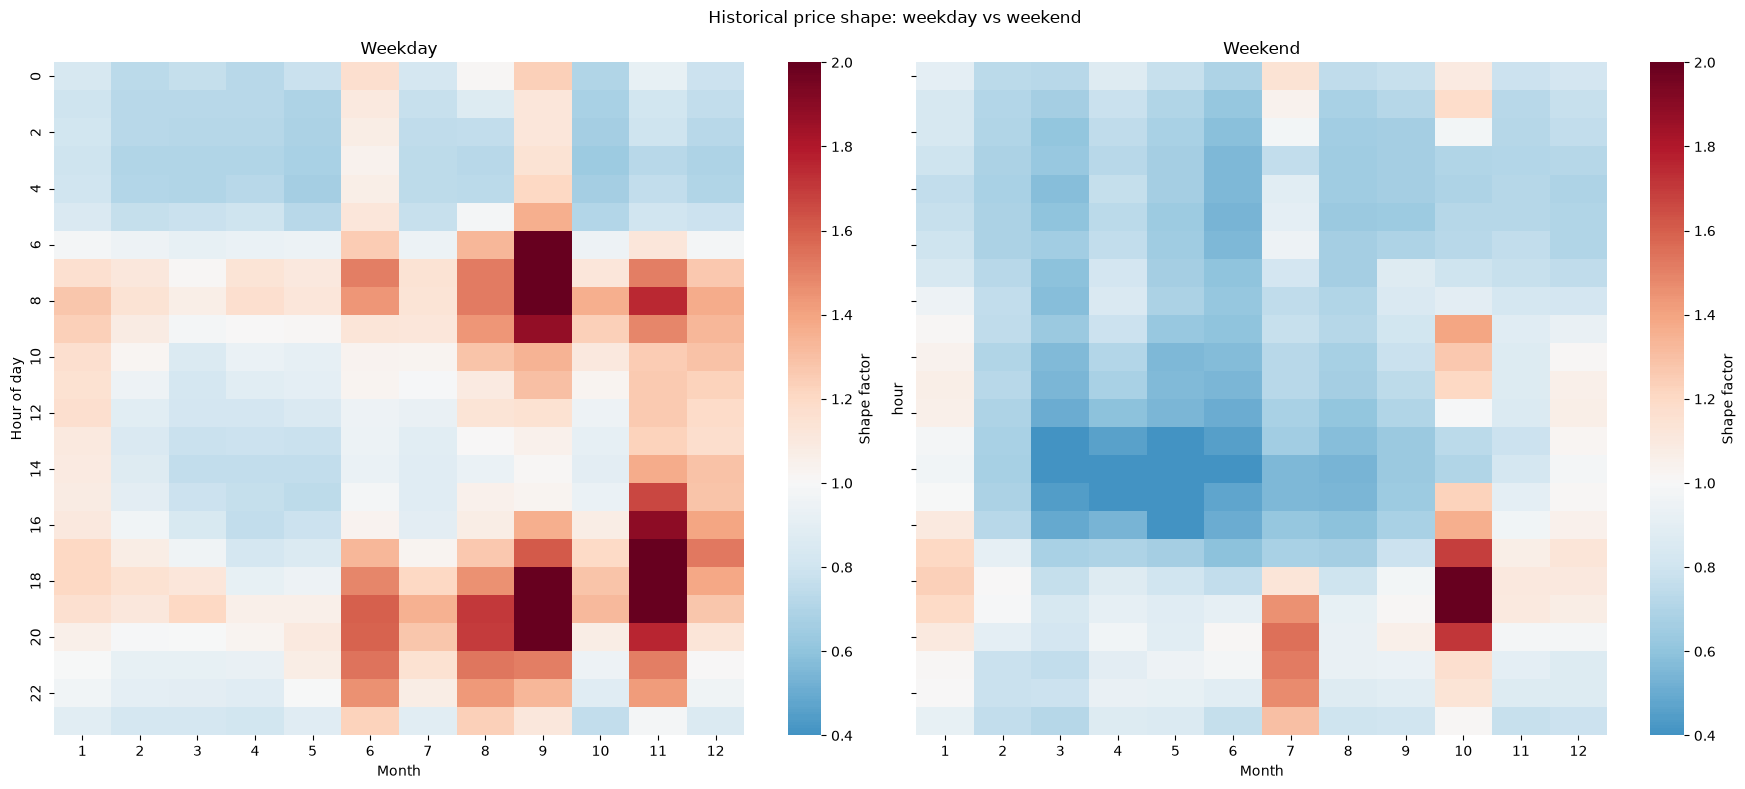

In [43]:
# Split by weekday vs weekend

pivot_weekday = shape[shape['weekday'] < 5].pivot_table(
    index='hour', columns='month', values='historical_shape_factor', aggfunc='mean'
)
pivot_weekend = shape[shape['weekday'] >= 5].pivot_table(
    index='hour', columns='month', values='historical_shape_factor', aggfunc='mean'
)
# same pivot as before, but filtered into two separate tables

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
sns.heatmap(pivot_weekday, cmap='RdBu_r', center=1.0, vmin=0.4, vmax=2.0,
            ax=axes[0], cbar_kws={'label': 'Shape factor'}, yticklabels=2)
axes[0].set_title("Weekday")
sns.heatmap(pivot_weekend, cmap='RdBu_r', center=1.0, vmin=0.4, vmax=2.0,
            ax=axes[1], cbar_kws={'label': 'Shape factor'}, yticklabels=2)
axes[1].set_title("Weekend")
# two heatmaps side by side, one for weekday and one for weekend, sharing the same y-axis
# vmin=0.4, vmax=2.0 on BOTH: forces the two charts to share the same color scale,
# so equal colors genuinely mean equal values across both panels. Makes them
# directly, visually comparable rather than each auto-scaling to its own data range

for ax in axes:
    ax.set_xlabel("Month")
    ax.invert_yaxis()
    # hour 0 at the top, hour 23 at the bottom
axes[0].set_ylabel("Hour of day")

plt.tight_layout()
plt.suptitle("Historical price shape: weekday vs weekend")
plt.tight_layout()
plt.show()


In [45]:
# Average shape factor by Peak vs Off-Peak

peak_avg = shape.groupby('is_peak')['historical_shape_factor'].mean()
print("Off-Peak average:", round(peak_avg[0], 3))
print("Peak average:", round(peak_avg[1], 3))
# is_peak: 1 = weekday 08:00-20:00, 0 = everything else (nights, weekends)

Off-Peak average: 0.907
Peak average: 1.167


In [46]:
# Weekday vs weekend overall average

weekday_avg = shape.loc[shape['weekday'] < 5, 'historical_shape_factor'].mean()
weekend_avg = shape.loc[shape['weekday'] >= 5, 'historical_shape_factor'].mean()

print('Weekday average:', weekday_avg)
print('Weekend average:', weekend_avg)

Weekday average: 1.0797844021644403
Weekend average: 0.7990046794711538


**Interpretation Exhibit 3**

*What values above and below one mean*
A shape factor above 1 means that hour/month combination has historically been more expensive than the yearly average; below 1 means historically cheaper. The factor is purely relative — it says nothing about the absolute EUR/MWh level, only how that slice of time compares to the rest of the year.

*Hours and seasons with high and low factors*

The heatmap shows a daily double-peak pattern in most months — a morning rise (roughly hour 7–9) and a stronger evening peak, with the evening peak's exact timing shifting seasonally (around hour 17–19 in winter, shifting later to roughly hour 19–21 in summer, plausibly tracking longer daylight hours). A deep overnight trough is consistent across all months (hours 0–5, factors as low as ~0.6–0.7). Winter months (Nov–Jan) run consistently above 1 across nearly all daytime hours. Spring months (Mar–May) show a pronounced midday dip well below 1 (particularly hours 13:00–16:00, dropping as low as 0.57–0.60), while morning and evening hours in these same months remain close to or slightly above the yearly average — the dip is concentrated around midday, not the whole day, plausibly reflecting solar generation depressing prices specifically during peak daylight hours. The single lowest value in the dataset is 0.12, in May at 14:00 on a Saturday. September stands out sharply: evening hours reach shape factors above 2 (peaking at 2.84 at 19:00 on a Monday) — far higher than any other month's evening peak, an anomaly almost certainly reflecting real extreme price events during the 2022 European energy crisis being folded into this 2019–2022 historical average.

*Relationship between the shape and the Peak definition*

Averaging by is_peak confirms the definition is well-chosen: Peak hours average a shape factor of ~1.17 (above the yearly average), while Off-Peak hours average ~0.91 (below it). The Peak window (weekday 08:00–20:00) was evidently defined to capture genuinely the more expensive hours of the day — the shape factor validates that Base/Peak is a meaningful split, not an arbitrary one.

*Differences between weekdays and weekends*

Weekdays average a shape factor of ~1.08, weekends ~0.80 — a sizeable gap. The weekday heatmap shows a sharper, more pronounced double-peak (especially the evening peak), while the weekend heatmap is flatter and generally lower throughout the day, with the morning peak largely absent — consistent with reduced commercial/industrial activity on weekends, mirroring the GB pattern already seen in Exhibit 1.

*How a relative shape factor helps transform block futures into an hourly curve*

A futures quote only gives you one price for an entire delivery block (a whole quarter, or a whole month). The shape factor supplies the missing piece — the relative timing information the futures market doesn't quote. By rescaling the shape factor within a block so its average equals 1, then multiplying by the quoted block price, you get a full hourly curve that (a) is consistent with the market-quoted price at the block level, and (b) distributes that price realistically across hours, using genuine historical demand/price patterns rather than an arbitrary flat spread. This is the mechanism you'll use later in the project to build the HPFC.


*Conclusion* 

What the historical shape adds beyond the average futures quotes
The futures quotes alone only tell you the average price level for a whole quarter or month — they carry no information about which specific hours within that block are relatively expensive or cheap. The historical shape factor supplies exactly that missing dimension: it shows that within any given block, evening hours (especially in winter) are reliably far more expensive than overnight hours, that midday hours in spring run notably cheaper due to what looks like a solar effect, and that weekday and weekend patterns diverge substantially. Without this shape information, you'd have no defensible way to convert a single block price into an hourly valuation curve — the shape factor is what turns a coarse quoted price into something usable for hour-by-hour decisions like hedge design and Day-Ahead cost forecasting.

# Exhibit 4

In [50]:
# Load both files

day_ahead = pd.read_csv(DATA_DIR / 'day_ahead_prices.csv')
imbalance = pd.read_csv(DATA_DIR / 'imbalance_prices.csv')

day_ahead["timestamp_local"] = pd.to_datetime(day_ahead["timestamp_local"], utc=True).dt.tz_convert("Europe/Berlin")
imbalance["timestamp_local"] = pd.to_datetime(imbalance["timestamp_local"], utc=True).dt.tz_convert("Europe/Berlin")
# same UTC-first conversion pattern as before, applied to both files

# check both loaded correctly before doing anything else

day_ahead.head()

,timestamp_utc,timestamp_local,day_ahead_price_eur_mwh
0,2023-12-31T23:00:00Z,2024-01-01 00:00:00+01:00,0.10
1,2023-12-31T23:15:00Z,2024-01-01 00:15:00+01:00,0.10
2,2023-12-31T23:30:00Z,2024-01-01 00:30:00+01:00,0.10
3,2023-12-31T23:45:00Z,2024-01-01 00:45:00+01:00,0.10
4,2024-01-01T00:00:00Z,2024-01-01 01:00:00+01:00,0.01


In [49]:
imbalance.head()

,timestamp_utc,timestamp_local,imbalance_price_eur_mwh
0,2023-12-31T23:00:00Z,2024-01-01 00:00:00+01:00,75.15
1,2023-12-31T23:15:00Z,2024-01-01 00:15:00+01:00,78.53
2,2023-12-31T23:30:00Z,2024-01-01 00:30:00+01:00,83.17
3,2023-12-31T23:45:00Z,2024-01-01 00:45:00+01:00,75.15
4,2024-01-01T00:00:00Z,2024-01-01 01:00:00+01:00,79.13


In [48]:
# Merge into one table for easy comparison

prices = day_ahead.merge(imbalance, on="timestamp_utc", suffixes=("", "_im"))
# merge on the shared timestamp_utc column, so each row has both prices side by side
# suffixes=("", "_im") avoids duplicate column name clashes on timestamp_local

prices.head()


,timestamp_utc,timestamp_local,day_ahead_price_eur_mwh,timestamp_local_im,imbalance_price_eur_mwh
0,2023-12-31T23:00:00Z,2024-01-01 00:00:00+01:00,0.10,2024-01-01 00:00:00+01:00,75.15
1,2023-12-31T23:15:00Z,2024-01-01 00:15:00+01:00,0.10,2024-01-01 00:15:00+01:00,78.53
2,2023-12-31T23:30:00Z,2024-01-01 00:30:00+01:00,0.10,2024-01-01 00:30:00+01:00,83.17
3,2023-12-31T23:45:00Z,2024-01-01 00:45:00+01:00,0.10,2024-01-01 00:45:00+01:00,75.15
4,2024-01-01T00:00:00Z,2024-01-01 01:00:00+01:00,0.01,2024-01-01 01:00:00+01:00,79.13


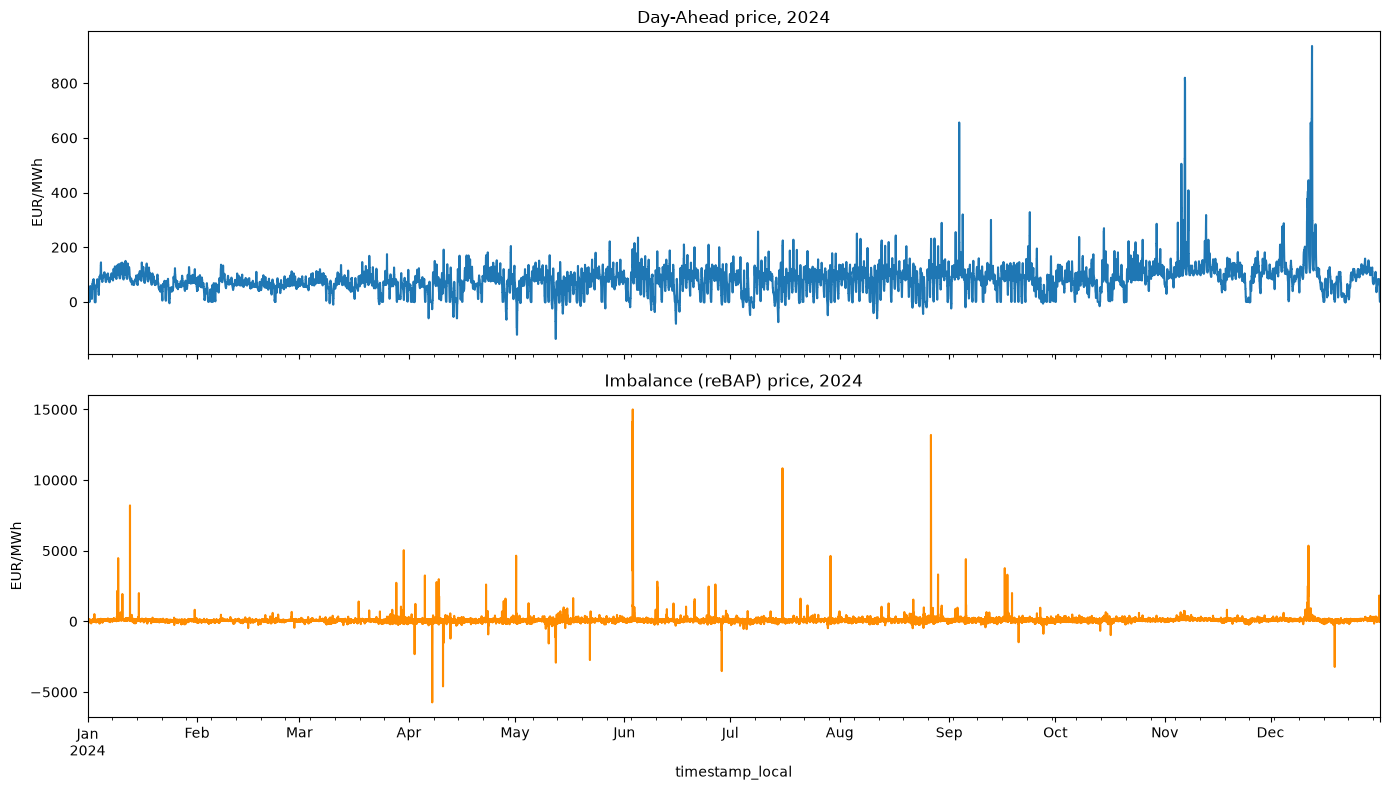

In [51]:
# time-series plot of both prives over the full year

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

day_ahead.set_index("timestamp_local")["day_ahead_price_eur_mwh"].plot(ax=axes[0], title="Day-Ahead price, 2024")
imbalance.set_index("timestamp_local")["imbalance_price_eur_mwh"].plot(ax=axes[1], title="Imbalance (reBAP) price, 2024", color="darkorange")
# two stacked line charts, sharing the same x-axis (time), so periods line up vertically

axes[0].set_ylabel("EUR/MWh")
axes[1].set_ylabel("EUR/MWh")
plt.tight_layout()
plt.show()

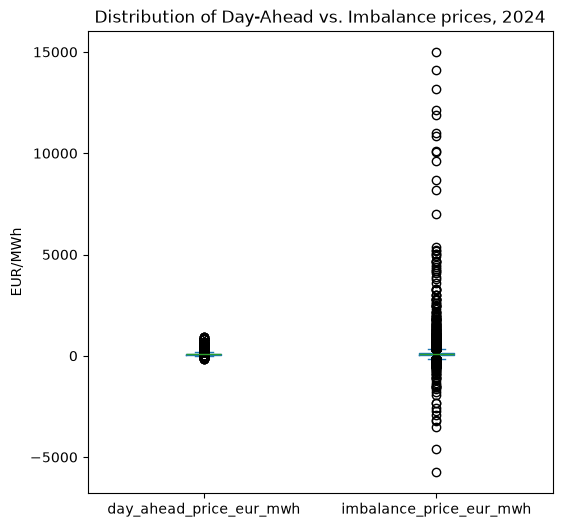

In [52]:
# Distributional view: box plot

prices[["day_ahead_price_eur_mwh", "imbalance_price_eur_mwh"]].plot(kind="box", figsize=(6, 6))
# box plot: shows median, the middle-50% range (the box), and outliers (dots) for both prices at once

plt.ylabel("EUR/MWh")
plt.title("Distribution of Day-Ahead vs. Imbalance prices, 2024")
plt.show()

In [53]:
# Quantile table, a precise complement ot the box plot

quantiles = prices[["day_ahead_price_eur_mwh", "imbalance_price_eur_mwh"]].quantile([0.01, 0.05, 0.5, 0.95, 0.99])
# .quantile([...]) computes several percentile cut-offs at once
# e.g. the 0.01 row shows the value only 1% of observations fall below

print(quantiles)

      day_ahead_price_eur_mwh  imbalance_price_eur_mwh
0.01                 -19.9855                -175.6365
0.05                  -0.0100                 -96.7100
0.50                  79.5850                  89.9550
0.95                 143.2500                 220.5300
0.99                 224.9180                 447.8470


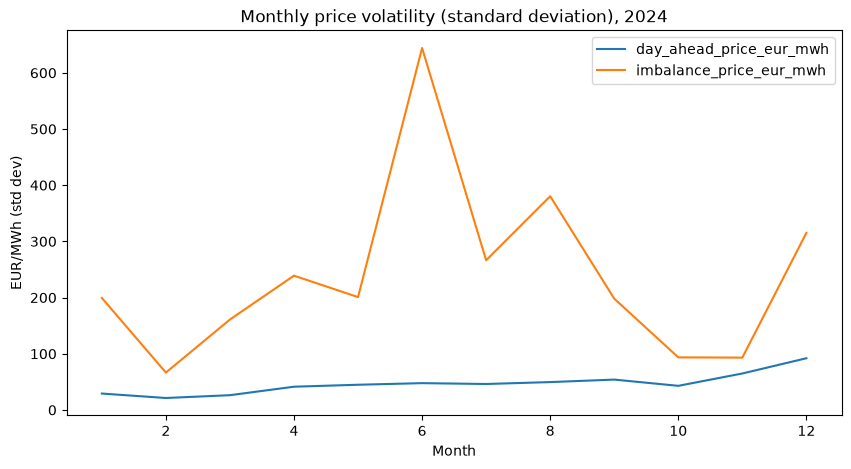

       day_ahead_price_eur_mwh  imbalance_price_eur_mwh
month                                                  
1                    29.203487               199.371586
2                    21.294188                66.548832
3                    26.287237               160.954406
4                    41.389465               239.026524
5                    44.873796               200.865036
6                    47.718720               644.187638
7                    46.210926               266.461328
8                    49.600017               380.341897
9                    54.057896               198.116457
10                   42.926590                93.596553
11                   64.917885                93.159803
12                   92.038408               315.179595


In [54]:
# Monthly volatility comparison

prices["month"] = prices["timestamp_local"].dt.month

monthly_std = prices.groupby("month")[["day_ahead_price_eur_mwh", "imbalance_price_eur_mwh"]].std()
# .std() within each month = how much prices swung around, month by month
# lets you see WHEN volatility was highest, not just how volatile the whole year was overall

monthly_std.plot(figsize=(10, 5))
plt.title("Monthly price volatility (standard deviation), 2024")
plt.ylabel("EUR/MWh (std dev)")
plt.xlabel("Month")
plt.show()

print(monthly_std)

In [55]:
# Find and inspect the most extreme individual prices

print("Day-Ahead min:", day_ahead.loc[day_ahead["day_ahead_price_eur_mwh"].idxmin()])
print("Day-Ahead max:", day_ahead.loc[day_ahead["day_ahead_price_eur_mwh"].idxmax()])
print()
print("Imbalance min:", imbalance.loc[imbalance["imbalance_price_eur_mwh"].idxmin()])
print("Imbalance max:", imbalance.loc[imbalance["imbalance_price_eur_mwh"].idxmax()])
# .idxmin()/.idxmax() find the ROW where the minimum/maximum occurs,
# so .loc[...] can pull out the full row — giving you the exact date/time of each extreme

Day-Ahead min: timestamp_utc                   2024-05-12T11:00:00Z
timestamp_local            2024-05-12 13:00:00+02:00
day_ahead_price_eur_mwh                      -135.45
Name: 12720, dtype: object
Day-Ahead max: timestamp_utc                   2024-12-12T16:00:00Z
timestamp_local            2024-12-12 17:00:00+01:00
day_ahead_price_eur_mwh                       936.28
Name: 33284, dtype: object

Imbalance min: timestamp_utc                   2024-04-07T12:15:00Z
timestamp_local            2024-04-07 14:15:00+02:00
imbalance_price_eur_mwh                     -5734.46
Name: 9365, dtype: object
Imbalance max: timestamp_utc                   2024-06-03T07:00:00Z
timestamp_local            2024-06-03 09:00:00+02:00
imbalance_price_eur_mwh                     14999.99
Name: 14816, dtype: object


**Exhibit 4 Interpretation**

*Extreme positive and negative prices*

Day-Ahead ranged from −135.45 EUR/MWh (12 May 2024, 13:00 local) to +936.28 EUR/MWh (12 December 2024, 17:00 local) — a swing of over 1,000 EUR/MWh across the year. Imbalance was far more extreme: from −5,734.46 EUR/MWh (7 April 2024, 14:15 local) to +14,999.99 EUR/MWh (3 June 2024, 09:00 local) — the imbalance price briefly spiked to over 15 times Day-Ahead's own maximum.

*Periods of elevated volatility*

Day-Ahead's monthly standard deviation shows a general upward trend across the year (from ~21–29 EUR/MWh in Jan–Mar up to 92 EUR/MWh in December — roughly 4.3× higher), though not perfectly smooth: both February and October dip noticeably below their neighboring months. Imbalance volatility follows a very different, spikier pattern with no clear seasonal trend — June stands out sharply (std ≈ 644 EUR/MWh, roughly 1.7× August's 380 and over 2× December's 315, the next-highest months), alongside other elevated months in April, May, and August (roughly 200–380). This confirms imbalance volatility is driven by isolated extreme events rather than a smooth seasonal progression.

*Whether reBAP is more variable than Day-Ahead*

Unambiguously yes, and by a wide margin. Day-Ahead's overall standard deviation across 2024 is ≈53 EUR/MWh; imbalance's is ≈283 EUR/MWh — more than 5 times larger. The 1st–99th percentile range tells the same story: Day-Ahead spans roughly −20 to +225 EUR/MWh, while imbalance spans roughly −176 to +448 EUR/MWh, and that's before even counting the far more extreme single-hour spikes seen in the min/max. This directly confirms the theoretical expectation from Part 3 of your information bank: imbalance settlement captures exactly the risk that no futures hedge can remove, and this data shows just how much larger that risk is in practice.

*One market episode worth investigating further*

The 3 June 2024 imbalance spike to 14,999.99 EUR/MWh (essentially hitting whatever cap exists on the reBAP price) stands out as the single most extreme event in either dataset — nearly 170 times the year's median imbalance price. Checking Day-Ahead at that same hour (09:00 local) shows a perfectly ordinary price of 128.08 EUR/MWh, confirming this was an isolated imbalance-side event with no corresponding Day-Ahead disturbance. This makes it a strong candidate for the Stage 7 "severe price event" analysis — both because of its sheer magnitude, and because understanding why it occurred (a large, sudden system imbalance — possibly a generation outage or a forecasting error at the grid level) would meaningfully inform how much residual imbalance risk a hedge strategy should be expected to absorb.

# Close the briefing

In [56]:
# Sanity checks performed across Exhibits 1-4 
# collected here for the briefing's "data checks" answer

# 1. SLP annual sums (should each be 1,000,000 kWh)
print(slp[["hb_normalized_kwh", "gb_normalized_kwh", "lb_normalized_kwh"]].sum())

# 2. Portfolio reconciliation (should equal 43,000 MWh)
print("Total portfolio energy:", slp["total_load_mwh"].sum())

# 3. Row counts (should all be 35,136 — the full 2024 quarter-hour grid)
for name, df in [("slp", slp), ("futures", futures), ("shape", shape),
                  ("day_ahead", day_ahead), ("imbalance", imbalance)]:
    print(name, "rows:", len(df))

# 4. Missing values check across the key files
print(slp.isna().sum().sum(), day_ahead.isna().sum().sum(), imbalance.isna().sum().sum())
# .isna() flags missing cells; summing twice collapses it to one number per file —
# 0 means no gaps in the data

hb_normalized_kwh    1000000.0
gb_normalized_kwh    1000000.0
lb_normalized_kwh    1000000.0
dtype: float64
Total portfolio energy: 43000.0
slp rows: 35136
futures rows: 34
shape rows: 35136
day_ahead rows: 35136
imbalance rows: 35136
0 0 0
